# Визуализация датасета: движение губ + текст

Ноутбук позволяет:
- Выбрать сэмпл из датасета по клипу и индексу
- Просмотреть анимацию кадров губ
- Увидеть текст (токены), соответствующий этому фрагменту
- Сохранить анимацию как GIF

In [9]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ── Параметры ──
DATASET_PATH = Path("D:/Datasets/Dataset_merged_bpe")   # объединённый датасет
TOKENIZER_PATH = "configs/bpe_tokenizer_merged/tokenizer.json"

# Загружаем BPE-токенизатор для декодирования
from tokenizers import Tokenizer
bpe_tokenizer = Tokenizer.from_file(TOKENIZER_PATH)

print(f"Датасет: {DATASET_PATH}")
print(f"Токенизатор: {TOKENIZER_PATH}")

Датасет: D:\Datasets\Dataset_merged_bpe
Токенизатор: configs/bpe_tokenizer_merged/tokenizer.json


In [10]:
# ── Список всех доступных сэмплов ──
all_samples = []
for clip_dir in sorted(DATASET_PATH.iterdir()):
    if not clip_dir.is_dir():
        continue
    for pkl_path in sorted(clip_dir.glob("*.pkl"),
                           key=lambda f: int(f.stem.split("_")[-1])):
        all_samples.append(pkl_path)

print(f"Всего сэмплов: {len(all_samples)}")
print(f"Первый: {all_samples[0].relative_to(DATASET_PATH)}")
print(f"Последний: {all_samples[-1].relative_to(DATASET_PATH)}")

Всего сэмплов: 1188
Первый: pt1\pt1_0.pkl
Последний: pt9\pt9_56.pkl


In [11]:
def load_sample(idx=None, clip=None, phrase_idx=None):
    """
    Загрузить сэмпл по глобальному индексу или по клипу+фразе.
    
    Примеры:
        load_sample(idx=0)                    # первый сэмпл
        load_sample(clip="pt16", phrase_idx=5) # pt16, фраза 5
    """
    if clip is not None and phrase_idx is not None:
        pkl_path = DATASET_PATH / clip / f"{clip}_{phrase_idx}.pkl"
        if not pkl_path.exists():
            print(f"Файл не найден: {pkl_path}")
            return None
    elif idx is not None:
        pkl_path = all_samples[idx]
    else:
        print("Укажите idx или (clip, phrase_idx)")
        return None
    
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    
    # Декодируем текст
    text = bpe_tokenizer.decode(data["input_ids"])
    tokens = [bpe_tokenizer.decode([tid]) for tid in data["input_ids"]]
    
    info = {
        "path": pkl_path,
        "clip": pkl_path.parent.name,
        "frames": data["frames"],          # list of np.ndarray (H, W, C)
        "num_frames": data["num_frames"],
        "input_ids": data["input_ids"],
        "text": text,
        "tokens": tokens,
    }
    
    print(f"Файл:     {pkl_path.relative_to(DATASET_PATH)}")
    print(f"Кадров:   {info['num_frames']}")
    print(f"Текст:    {repr(text)}")
    print(f"Токены:   {tokens}")
    print(f"IDs:      {data['input_ids']}")
    print(f"Размер кадра: {data['frames'][0].shape}")
    
    return info

## Выбор сэмпла

Измените параметры ниже, чтобы выбрать нужный сэмпл.

In [12]:
# ── Вариант 1: по глобальному индексу ──
# sample = load_sample(idx=0)

# ── Вариант 2: по клипу и номеру фразы ──
sample = load_sample(clip="pt1", phrase_idx=0)

Файл:     pt1\pt1_0.pkl
Кадров:   50
Текст:    'hello and a very warm welcome to bbc'
Токены:   ['hello', 'and', 'a', 'very', 'warm', 'welcome', 'to', 'bbc']
IDs:      [663, 56, 15, 187, 649, 379, 52, 125]
Размер кадра: (64, 96, 3)


## Сетка кадров (статичный обзор)

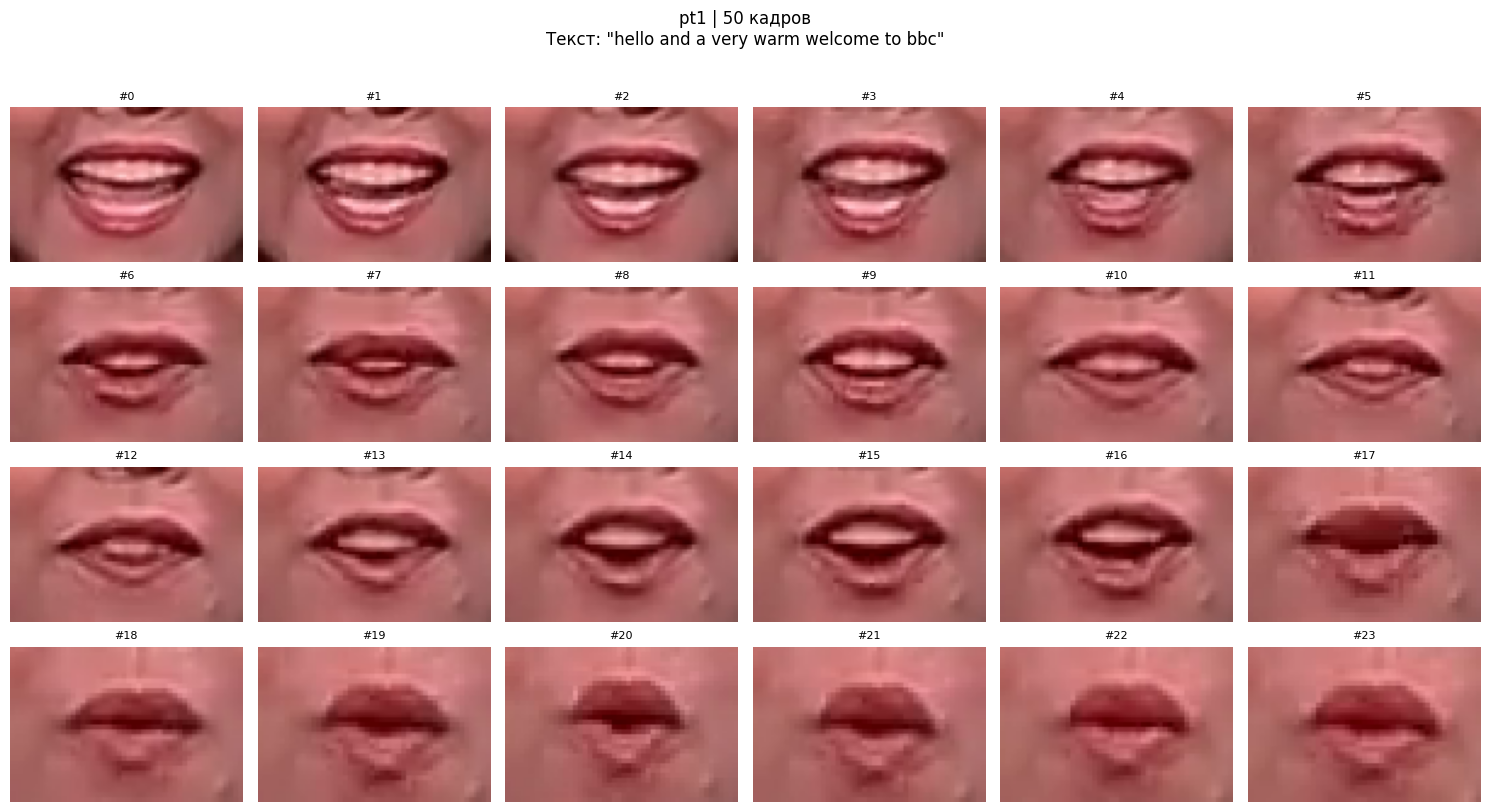

In [13]:
def show_frame_grid(sample, max_frames=24, cols=6):
    """Показать сетку кадров из сэмпла."""
    frames = sample["frames"]
    n = min(len(frames), max_frames)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2))
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(
        f"{sample['clip']} | {sample['num_frames']} кадров\n"
        f"Текст: \"{sample['text']}\"",
        fontsize=12, y=1.02
    )
    
    for i, ax in enumerate(axes.flat):
        if i < n:
            frame = frames[i]
            if frame.dtype == np.uint8:
                frame = cv2_to_rgb(frame)
            ax.imshow(frame)
            ax.set_title(f"#{i}", fontsize=8)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

def cv2_to_rgb(frame):
    """BGR → RGB если нужно (OpenCV сохраняет в BGR)."""
    if len(frame.shape) == 3 and frame.shape[2] == 3:
        return frame[:, :, ::-1]
    return frame

show_frame_grid(sample)

## Анимация (видео движения губ)

In [ ]:
def get_token_for_frame(frame_idx, num_frames, tokens):
    """Определить какой токен произносится на данном кадре.
    Токены распределяются равномерно по кадрам."""
    if not tokens:
        return ""
    token_idx = int(frame_idx / num_frames * len(tokens))
    token_idx = min(token_idx, len(tokens) - 1)
    return tokens[token_idx]


def format_token_line(frame_idx, num_frames, tokens):
    """Показать все токены, текущий выделен [ ]."""
    if not tokens:
        return ""
    current_idx = int(frame_idx / num_frames * len(tokens))
    current_idx = min(current_idx, len(tokens) - 1)
    parts = []
    for i, t in enumerate(tokens):
        if i == current_idx:
            parts.append(f"[{t}]")
        else:
            parts.append(t)
    return " ".join(parts)


def animate_sample(sample, fps=12, figsize=(7, 5)):
    """
    Анимация кадров губ с наложением текущего токена.
    Текущий токен отображается на кадре и в заголовке.
    """
    frames = sample["frames"]
    n = len(frames)
    tokens = sample["tokens"]
    text = sample["text"]

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    first = cv2_to_rgb(frames[0]) if frames[0].dtype == np.uint8 else frames[0]
    img = ax.imshow(first)
    ax.axis("off")

    # Текст токена поверх кадра (белый на полупрозрачном фоне)
    token_text = ax.text(
        0.5, 0.07, "",
        transform=ax.transAxes,
        fontsize=16, fontweight="bold",
        color="white",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
    )

    title = ax.set_title("", fontsize=10)

    plt.tight_layout()

    def update(i):
        frame = frames[i]
        if frame.dtype == np.uint8:
            frame = cv2_to_rgb(frame)
        img.set_data(frame)

        current_token = get_token_for_frame(i, n, tokens)
        token_text.set_text(current_token)

        title.set_text(
            f"{sample['clip']} | Кадр {i+1}/{n}  "
            + format_token_line(i, n, tokens)
        )
        return [img, token_text, title]

    anim = FuncAnimation(
        fig, update,
        frames=n,
        interval=1000 // fps,
        blit=False,
        repeat=True,
    )

    plt.close(fig)
    return anim


sample = load_sample(clip="pt16", phrase_idx=1)

anim = animate_sample(sample, fps=12)
display(HTML(anim.to_jshtml()))


## Сохранить как GIF

In [19]:
def save_gif(sample, output_path=None, fps=12):
    """Сохранить анимацию как GIF с наложением токенов."""
    if output_path is None:
        output_path = f"viz_{sample['clip']}_{sample['path'].stem.split('_')[-1]}.gif"

    anim = animate_sample(sample, fps=fps)
    anim.save(output_path, writer="pillow", fps=fps)
    print(f"Сохранено: {output_path}")


save_gif(sample)  # раскомментировать для сохранения


Сохранено: viz_pt2_0.gif


## Быстрый обзор нескольких сэмплов

In [ ]:
def overview(clips=None, n_per_clip=3):
    """
    Показать по n_per_clip сэмплов из каждого клипа:
    первый кадр + текст.
    """
    if clips is None:
        clips = sorted(set(p.parent.name for p in all_samples))
    
    rows = []
    for clip in clips:
        clip_dir = DATASET_PATH / clip
        if not clip_dir.exists():
            continue
        pkls = sorted(clip_dir.glob("*.pkl"),
                      key=lambda f: int(f.stem.split("_")[-1]))
        for pkl in pkls[:n_per_clip]:
            with open(pkl, "rb") as f:
                d = pickle.load(f)
            text = bpe_tokenizer.decode(d["input_ids"])
            rows.append((clip, pkl.stem, d["num_frames"], d["frames"][0], text))
    
    n = len(rows)
    cols = min(n, 4)
    fig_rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(fig_rows, cols, figsize=(cols * 3, fig_rows * 2.5))
    if fig_rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif fig_rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, ax in enumerate(axes.flat):
        if i < n:
            clip, name, nf, frame, text = rows[i]
            frame_rgb = cv2_to_rgb(frame) if frame.dtype == np.uint8 else frame
            ax.imshow(frame_rgb)
            ax.set_title(f"{name} ({nf}f)\n{text[:30]}...", fontsize=7)
        ax.axis("off")
    
    plt.suptitle("Обзор датасета: первый кадр + текст", fontsize=12)
    plt.tight_layout()
    plt.show()

# Обзор: 2 сэмпла из каждого клипа (старые + новые)
overview(clips=["pt2"], n_per_clip=2)
# overview(clips=["pt1", "pt5", "pt12", "pt16", "pt19", "pt21"], n_per_clip=2)